# Sensitivity Analysis

The goal is to check whether the assumptions of ANOVA are reasonable and whether the results are robust to violations.

In [20]:
library(haven)
library(ggplot2)
library(dplyr)
library(plotly)

knitr::opts_chunk$set(echo = TRUE)

In [21]:
df_highschools <- read_sav("./data/STAR_High_Schools.sav")
df_comp_students <- read_sav("./data/Comparison_Students.sav")
df_students <- read_sav("./data/STAR_Students.sav")
df_k3schools <- read_sav("./data/STAR_K-3_Schools.sav")

Failed to find CITYPOP
Failed to find COUNTYPO
Failed to find SCHOOLTY
Failed to find HIGHGRAD
Failed to find GRADELEV
Failed to find MINORITY
Failed to find MINORI_A
Failed to find MINORI_B
Failed to find ENROLLME
Failed to find MEALNUM
Failed to find MEANPCT
Failed to find MEALESTI
Failed to find MINREQUI
Failed to find MATHCRGR
Failed to find SCIENCCR
Failed to find FORLANGC
Failed to find SOCSTUDC
Failed to find COMPUTER
Failed to find ENGLISHC
Failed to find MATHCRUN
Failed to find SCIENCEC
Failed to find FORLAN_A
Failed to find SOCSTU_A
Failed to find COMPUT_A
Failed to find ENGLIS_A
Failed to find NOTGRADN
Failed to find UNIFIEDP
Failed to find LINEARAL
Failed to find OTHERMAT
Failed to find COURSE1
Failed to find COURSE2
Failed to find COURSE3
Failed to find COURSE4
Failed to find COURSE5
Failed to find COURSE6
Failed to find COURSE7
Failed to find COURSE8
Failed to find COURSE9
Failed to find COURSE10
Failed to find COURSE11
Failed to find COURSE12
Failed to find COURSE13
Fail

Failed to find G1READ_A
Failed to find G1MATH_A
Failed to find G2READ_A
Failed to find G3READ_A
Failed to find G3MATH_A
Failed to find FILTER_$
Failed to find G1READ_A
Failed to find G1MATH_A
Failed to find G2READ_A
Failed to find G2MATH_A
Failed to find G3READ_A
Failed to find G3MATH_A
Failed to find SCHOOLTY
Failed to find GRADERAN
Failed to find ENROLLME
Failed to find ATTENDAN
Failed to find MEMBERSH
Failed to find CHAPTER1
Failed to find LUNCH
Failed to find BUSED
Failed to find NATIVEAM
Failed to find ASIAN
Failed to find BLACK
Failed to find HISPANIC
Failed to find WHITE
Failed to find OTHERRAC
Failed to find GRADEFIL


## Cleaning the Data

The code below produces the same cleaned dataset we used for the **inferential analysis**.  In particular:

* Those who left the study (i.e., K-3) early or joined late were removed.
* Those in regular sized classes with a teacher's aid were removed.

In [30]:
# Filter for no aide
had_aide <- df_students$gkclasstype == 3 | 
  df_students$g1classtype == 3 | 
  df_students$g2classtype == 3 | 
  df_students$g3classtype == 3

df_students_noaide <- df_students[!had_aide,]

# Filter for no aide and were in study all 4 years
df_students_noaide_4years <- df_students[
  !had_aide &
  !is.na(df_students$gkclasstype) &
  !is.na(df_students$g1classtype) &
  !is.na(df_students$g2classtype) &
  !is.na(df_students$g3classtype),
]

# Drop races that are not sufficiently represented
df_students_noaide_4years <- df_students_noaide_4years[
  df_students_noaide_4years$race %in% c(1, 2),
]

# Make race a categorical variable
df_students_noaide_4years$race <- factor(
  df_students_noaide_4years$race,
  levels = c(1, 2),
  labels = c("White", "Black")
)

# Make gender a categorical variable
df_students_noaide_4years$gender <- factor(
  df_students_noaide_4years$gender,
  levels = c(1, 2),
  labels = c("Male", "Female")
)

## Sankey Diagram on Attrition

<!-- This was motivated by a diagram I saw in one of the presentations, so if we want to omit it, that's fine with me.  I do think it is helpful to visualize the group we are interested in. -->

Below we visualize the attrition of students from their existing path at the end of each grade.

In [31]:
class_labels <- c(
  "1" = "Small Class",
  "2" = "Regular Class",
  "3" = "Regular Class with Aid"
)

# Prepare data for sankey diagram
df_sankey <- df_students_noaide_4years %>%
  select(gkclasstype, g1classtype, g2classtype, g3classtype) %>%
  mutate(across(everything(), ~ class_labels[as.character(.)]))

# Create node labels
nodes <- unique(c(
  df_sankey$gkclasstype,
  df_sankey$g1classtype,
  df_sankey$g2classtype,
  df_sankey$g3classtype
))

flows <- list()

# Kindergarten to 1st grade
flow1 <- df_sankey %>%
  group_by(gkclasstype, g1classtype) %>%
  summarise(count = n(), .groups = "drop") %>%
  mutate(
    source = match(gkclasstype, nodes) - 1,
    target = (
      match(g1classtype, nodes) - 1 + length(unique(df_sankey$gkclasstype))
    )
  )

# 1st grade to 2nd grade
flow2 <- df_sankey %>%
  group_by(g1classtype, g2classtype) %>%
  summarise(count = n(), .groups = "drop") %>%
  mutate(
    source = (
      match(g1classtype, nodes) - 1 + length(unique(df_sankey$gkclasstype))
    ),
    target = (
      match(g2classtype, nodes) - 1 + 2 * length(unique(df_sankey$gkclasstype))
    )
  )

# 2nd grade to 3rd grade
flow3 <- df_sankey %>%
  group_by(g2classtype, g3classtype) %>%
  summarise(count = n(), .groups = "drop") %>%
  mutate(
    source = (
      match(g2classtype, nodes) - 1 + 2 * length(unique(df_sankey$gkclasstype))
    ),
    target = (
      match(g3classtype, nodes) - 1 + 3 * length(unique(df_sankey$gkclasstype))
    )
  )

# Combine flows
all_flows <- bind_rows(flow1, flow2, flow3)

# Create node labels with grade information
node_labels <- c(
  paste("Kindergarten:", nodes),
  paste("First Grade:", nodes),
  paste("Second Grade:", nodes),
  paste("Third Grade:", nodes)
)

# Create Sankey diagram
fig <- plot_ly(
  type = "sankey",
  node = list(
    label = node_labels,
    color = "darkgray"
  ),
  link = list(
    source = all_flows$source,
    target = all_flows$target,
    value = all_flows$count,
    color = rep(c("pink", "lightgreen", "pink", "lightgreen"), times = 3)
  )
)

# Add title and subtitle using HTML tags in the layout() function
fig <- fig %>%
  layout(
    title = list(
      text = "Compliance and Attrition",
      font = list(size = 16)
    )
  )

fig

HTML widgets cannot be represented in plain text (need html)

## Model Diagnostics

### Fitting the ANOVA model from the inferential analysis

In [77]:
# Waiting on confirmation of final model before updating.

# Not significant:
#   * Interaction term (classtype * freelunch),
#   * gender
#   * suburban

model <- aov(
  gktmathss ~ (
    gkclasstype
    * gkfreelunch
    * race
    # + gender
    # + gksurban
  ),
  data = df_students_noaide_4years
)

summary(model)

                               Df  Sum Sq Mean Sq F value   Pr(>F)    
gkclasstype                     1   37240   37240  19.066 1.36e-05 ***
gkfreelunch                     1   95666   95666  48.979 4.08e-12 ***
race                            1   13349   13349   6.834  0.00904 ** 
gkclasstype:gkfreelunch         1      60      60   0.031  0.86133    
gkclasstype:race                1     299     299   0.153  0.69551    
gkfreelunch:race                1     888     888   0.455  0.50015    
gkclasstype:gkfreelunch:race    1    1876    1876   0.960  0.32726    
Residuals                    1334 2605543    1953                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
84 observations deleted due to missingness

### Checking Model Assumptions

Two-way ANOVA relies on several assumptions:

1. Independence of observations (*guaranteed by randomness of RCT*)
2. Normality of residuals (*not important if not testing*)
3. Homogeneity of variance
4. Absence of influential outliers

Diagnostics focus mainly on residual analysis.

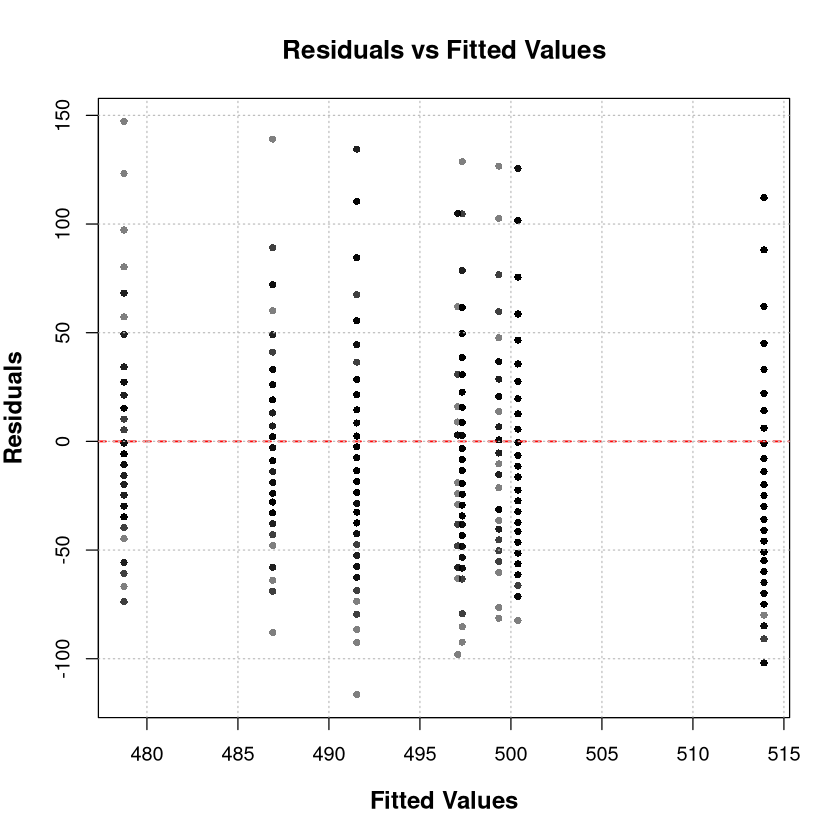

In [78]:
# Residuals vs fitted value
# Homoscedasticity: residuals should have constant variance
# across fitted values, which appears to be true
res <- residuals(model)
fit <- fitted(model)

plot(
  fit,
  res,
  xlab = "Fitted Values",
  ylab = "Residuals",
  main = "Residuals vs Fitted Values",
  pch = 16,
  cex = 0.8,
  col = rgb(0, 0, 0, 0.5),
  cex.lab = 1.2,
  cex.main = 1.3,
  font.lab = 2
)
abline(h = 0, col = "red", lty = 2, lwd = 1.5)
grid(lty = 3, col = "gray")

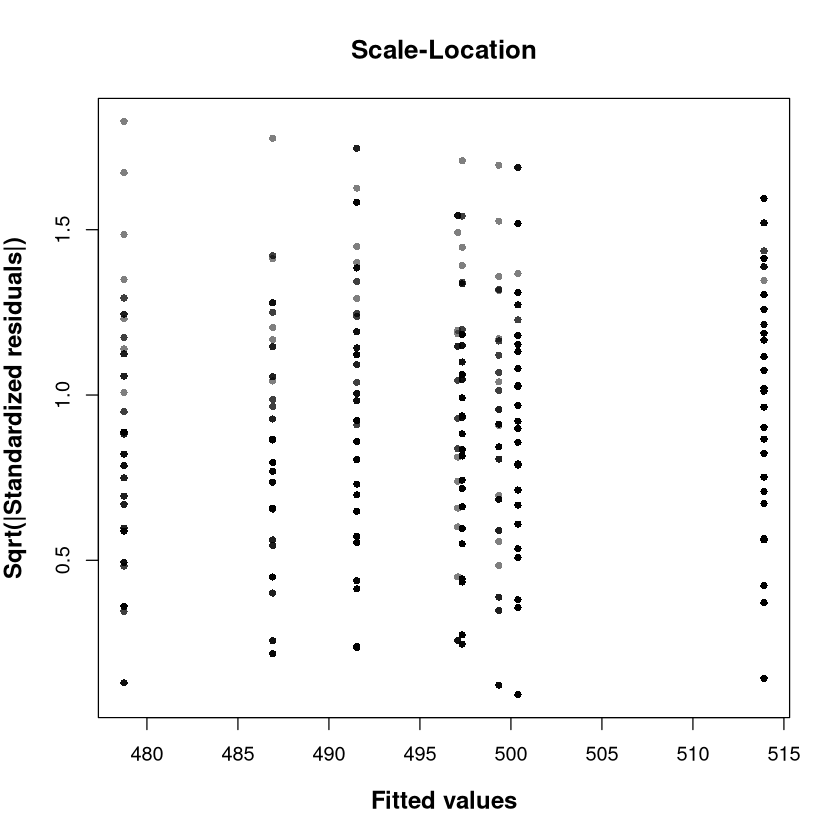

In [79]:
# Scale-location (homoscedasticity)
plot(
  fit,
  sqrt(abs(scale(res))),
  xlab = "Fitted values",
  ylab = "Sqrt(|Standardized residuals|)",
  main = "Scale-Location",
  pch = 16,
  cex = 0.8,
  col = rgb(0, 0, 0, 0.5),
  cex.lab = 1.2,
  cex.main = 1.3,
  font.lab = 2
)

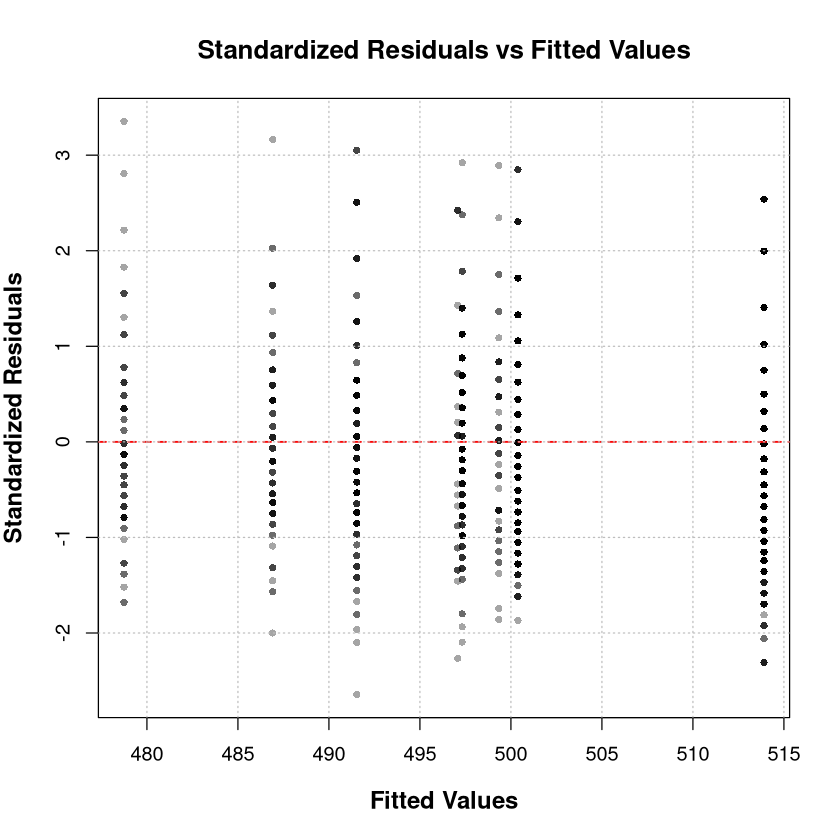

In [80]:
# Outliers may be present, but not many of them.
plot(
  fit,
  rstandard(model),
  xlab = "Fitted Values",
  ylab = "Standardized Residuals",
  main = "Standardized Residuals vs Fitted Values",
  pch = 16,
  cex = 0.8,
  col = rgb(0, 0, 0, 0.35),
  cex.lab = 1.2,
  cex.main = 1.3,
  font.lab = 2
)

abline(h = 0, col = "red", lty = 2, lwd = 1.5)
grid(lty = 3, col = "gray")

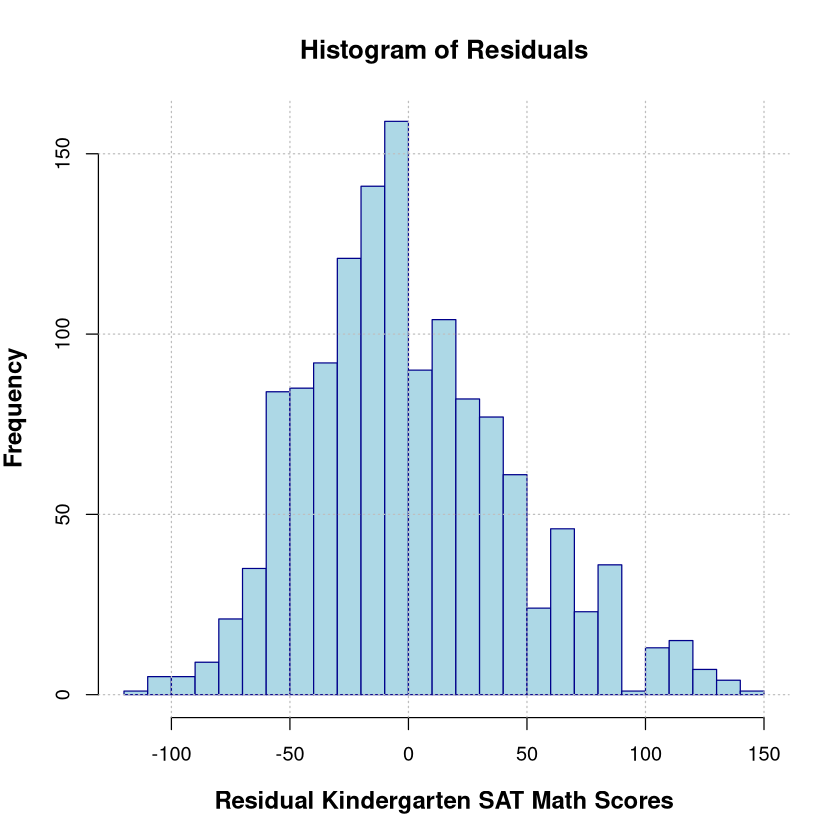

In [81]:
# Residual distribution
hist(
  res,
  breaks = 30,
  main = "Histogram of Residuals",
  xlab = "Residual Kindergarten SAT Math Scores",
  ylab = "Frequency",
  col = "lightblue",
  border = "darkblue",
  cex.lab = 1.2,
  cex.main = 1.3,
  font.lab = 2
)
grid(lty = 3, col = "gray")

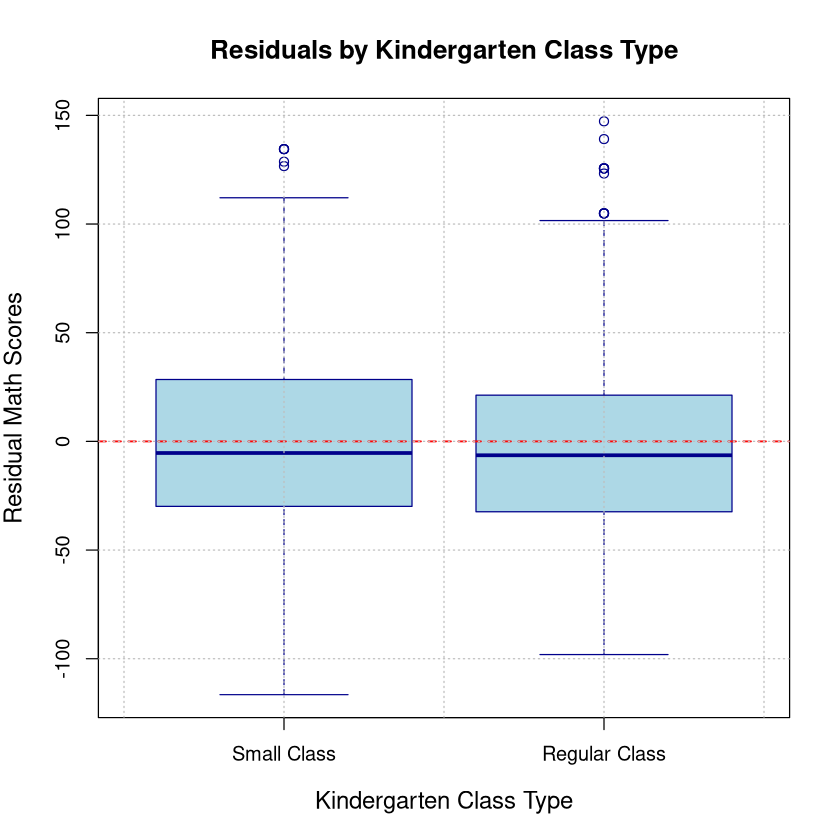

In [82]:
# Residual spread by class type
boxplot(
  res ~ model$model$gkclasstype,
  main = "Residuals by Kindergarten Class Type",
  xlab = "Kindergarten Class Type",
  ylab = "Residual Math Scores",
  names = c("Small Class", "Regular Class"),
  col = "lightblue",
  border = "darkblue",
  cex.lab = 1.2,
  cex.main = 1.3,
  font.lab = 2
)
abline(h = 0, col = "red", lty = 2, lwd = 1.5)
grid(lty = 3, col = "gray")

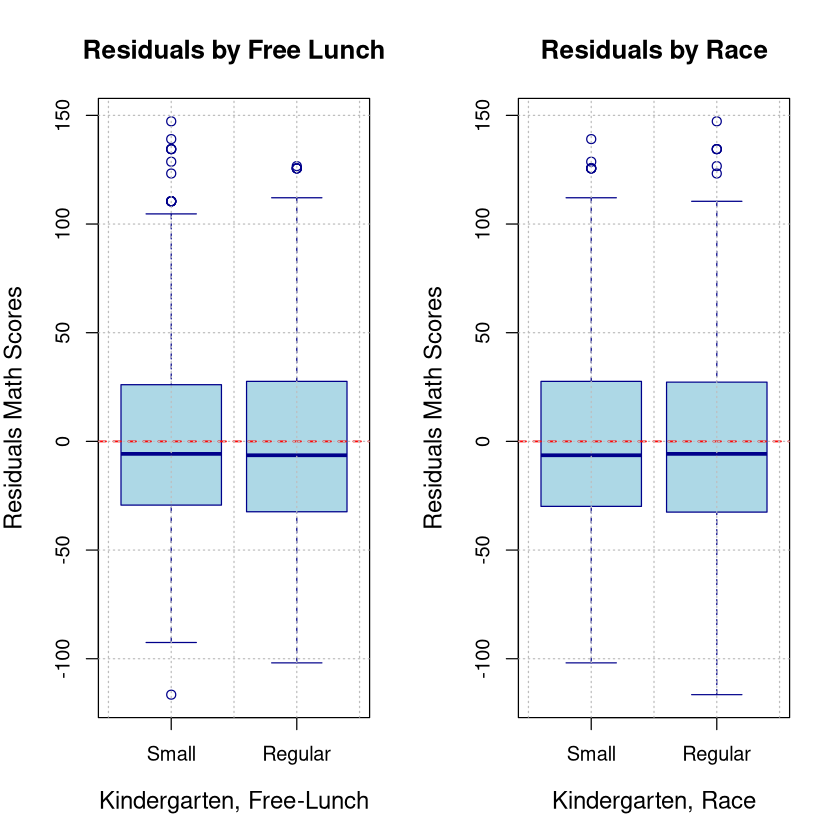

In [83]:
# Residual spread

par(mfrow = c(1, 2))

boxplot(
  res ~ model$model$gkfreelunch,
  main = "Residuals by Free Lunch",
  xlab = "Kindergarten, Free-Lunch",
  ylab = "Residuals Math Scores",
  names = c("Small", "Regular"),
  col = "lightblue",
  border = "darkblue",
  cex.lab = 1.2,
  cex.main = 1.3,
  font.lab = 2
)
abline(h = 0, col = "red", lty = 2, lwd = 1.5)
grid(lty = 3, col = "gray")

boxplot(
  res ~ model$model$race,
  main = "Residuals by Race",
  xlab = "Kindergarten, Race",
  ylab = "Residuals Math Scores",
  names = c("Small", "Regular"),
  col = "lightblue",
  border = "darkblue",
  cex.lab = 1.2,
  cex.main = 1.3,
  font.lab = 2
)
abline(h = 0, col = "red", lty = 2, lwd = 1.5)
grid(lty = 3, col = "gray")

par(mfrow = c(1, 1))

#### 3.2 Normality of Residuals

**Shapiro-Wilk Test**

Notes:

* Test is very sensitive to large sample size.
* Graphical checks preferred.

In [85]:
# p-value = 10^{-12} implies NOT normally distributed
shapiro.test(res)


	Shapiro-Wilk normality test

data:  res
W = 0.98036, p-value = 1.506e-12


---

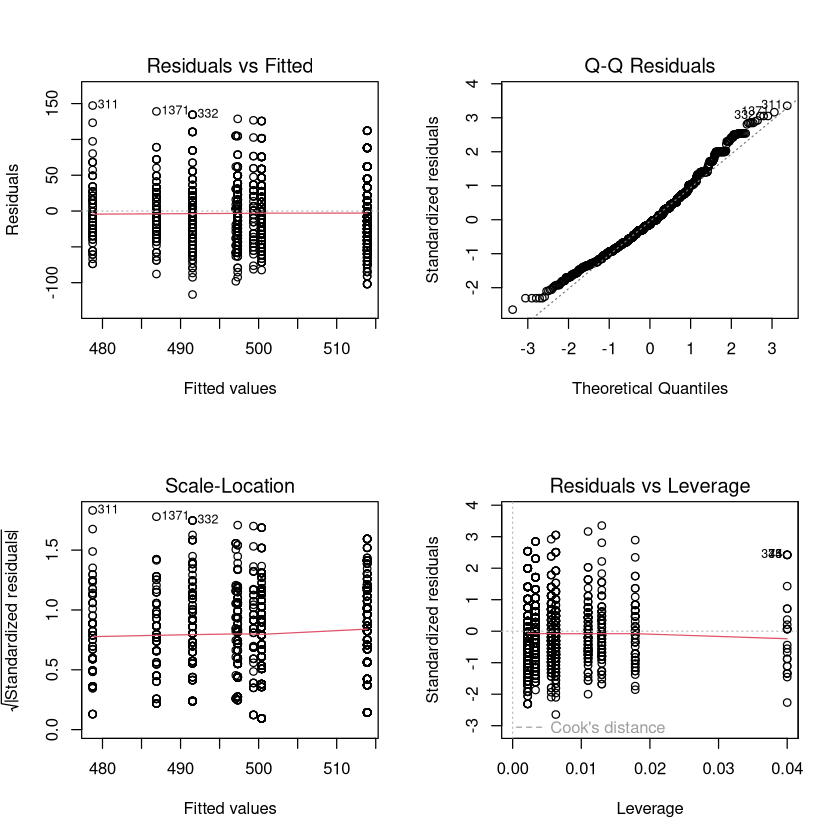

In [86]:
par(mfrow = c(2,2))
plot(model)
par(mfrow = c(1,1))